# Финальный проект. Этап 2 — Описательная статистика

**Цель этапа:** получить количественное представление о каждом датасете —
что типично, что является выбросом, как распределены ключевые показатели.

**Данные:** очищенные CSV из `data_clean/` (результат этапа 1).

**План:**
1. Загрузка очищенных данных
2. Числовые переменные: меры центра и разброса
3. Распределения числовых переменных (гистограммы + боксплоты)
4. Категориальные переменные: частотный анализ и столбчатые диаграммы
5. Анализ звонков: длительность и тип
6. Анализ маркетинговых расходов
7. Сводные выводы


## 1. Загрузка очищенных данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Настраиваем стиль графиков — нейтральный и читаемый
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11


In [2]:
# Пути к очищенным файлам (относительно корня проекта)
DATA_CLEAN = '../data_clean/'

# Читаем все четыре датасета
deals = pd.read_csv(DATA_CLEAN + 'deals_clean.csv', low_memory=False)
calls = pd.read_csv(DATA_CLEAN + 'calls_clean.csv', low_memory=False)
contacts = pd.read_csv(DATA_CLEAN + 'contacts_clean.csv', low_memory=False)
spend = pd.read_csv(DATA_CLEAN + 'spend_clean.csv', low_memory=False)

print('Deals:   ', deals.shape)
print('Calls:   ', calls.shape)
print('Contacts:', contacts.shape)
print('Spend:   ', spend.shape)


Deals:    (21593, 27)
Calls:    (95874, 9)
Contacts: (18548, 4)
Spend:    (19862, 8)


In [3]:
# Проверяем список колонок каждого датасета
print('=== Deals ===')
print(deals.dtypes.to_string())


=== Deals ===
Id                       int64
Deal Owner Name         object
Closing Date            object
Quality                 object
Stage                   object
Lost Reason             object
Page                    object
Campaign                object
Content                 object
Term                    object
Source                  object
Payment Type            object
Product                 object
Education Type          object
Created Time            object
Course duration        float64
Months of study        float64
Initial Amount Paid    float64
Offer Total Amount     float64
Contact Name           float64
City                    object
Level of Deutsch        object
SLA (seconds)          float64
Is Demo                   bool
Closing Date Error        bool
Amount Error              bool
Deutsch Level           object


In [4]:
print('=== Calls ===')
print(calls.dtypes.to_string())


=== Calls ===
Id                              int64
Call Start Time                object
Call Owner Name                object
CONTACTID                     float64
Call Type                      object
Call Duration (in seconds)    float64
Call Status                    object
Outgoing Call Status           object
Scheduled in CRM              float64


In [5]:
print('=== Spend ===')
print(spend.dtypes.to_string())


=== Spend ===
Date            object
Source          object
Campaign        object
Impressions      int64
Spend          float64
Clicks           int64
AdGroup         object
Ad              object


## 2. Числовые переменные: меры центра и разброса

Начнём с тех полей, которые несут финансовый и операционный смысл:
- **IAP** (Initial Amount Paid) — первый платёж студента;
- **OTA** (Offer Total Amount) — полная стоимость по предложению;
- **SLA_seconds** — время до первого контакта (в секундах);
- **Call Duration** — длительность звонка;
- **Course Duration / Months of Study** — срок обучения.

Для Spend: Spend, Clicks, Impressions.


In [6]:
# Числовые поля Deals — только те, что несут содержательный смысл
num_deals = ['Initial Amount Paid', 'Offer Total Amount',
             'SLA (seconds)', 'Course duration', 'Months of study']

# describe() даёт сразу count, mean, std, min, квартили, max
deals[num_deals].describe().round(2)


,Initial Amount Paid,Offer Total Amount,SLA (seconds),Course duration,Months of study
count,4165.00,4127.00,15533.00,3587.00,840.00
mean,950.09,7145.31,115826.22,10.20,5.44
std,1422.15,4638.50,737252.64,1.83,2.92
min,0.00,0.00,3.00,6.00,0.00
25%,300.00,3000.00,4380.00,11.00,3.00
50%,1000.00,11000.00,19894.00,11.00,5.00
75%,1000.00,11000.00,56318.00,11.00,8.00
max,11500.00,11500.00,26908464.00,11.00,11.00


In [7]:
# Проверяем, сколько не-NaN значений в каждом поле
# (важно для оценки репрезентативности статистики)
not_null = deals[num_deals].notna().sum()

pct_filled = (not_null / len(deals) * 100).round(1)

summary = pd.DataFrame({'Непустых значений': not_null, '% заполнения': pct_filled})
print(summary.to_string())


                     Непустых значений  % заполнения
Initial Amount Paid               4165          19.3
Offer Total Amount                4127          19.1
SLA (seconds)                    15533          71.9
Course duration                   3587          16.6
Months of study                    840           3.9


In [8]:
# Медиана и мода дополняют среднее — полезны при скошенных распределениях
for col in ['Initial Amount Paid', 'Offer Total Amount']:
    vals = deals[col].dropna()
    print(f'{col}:')
    print(f'  mean   = {vals.mean():.2f}')
    print(f'  median = {vals.median():.2f}')
    mode_val = vals.mode()
    print(f'  mode   = {mode_val.values[0] if len(mode_val) > 0 else "нет"}')
    print(f'  std    = {vals.std():.2f}')
    print()


Initial Amount Paid:
  mean   = 950.09
  median = 1000.00
  mode   = 1000.0
  std    = 1422.15

Offer Total Amount:
  mean   = 7145.31
  median = 11000.00
  mode   = 11000.0
  std    = 4638.50



### Интерпретация: финансовые поля

In [9]:
# Сравниваем IAP и OTA — разница показывает долю оплативших не полностью
iap_median = deals['Initial Amount Paid'].median()
ota_median = deals['Offer Total Amount'].median()

print(f'Медиана IAP: {iap_median:.0f}')
print(f'Медиана OTA: {ota_median:.0f}')
print(f'Соотношение IAP/OTA (медианы): {iap_median / ota_median:.1%}')


Медиана IAP: 1000
Медиана OTA: 11000
Соотношение IAP/OTA (медианы): 9.1%


### SLA (время реакции)

In [10]:
# SLA — время в секундах от создания сделки до первого контакта
# Переводим в часы для удобного чтения
sla = deals['SLA (seconds)'].dropna()

print('SLA (секунды):')
print(f'  Среднее:  {sla.mean():.0f} сек  ({sla.mean()/3600:.1f} ч)')
print(f'  Медиана:  {sla.median():.0f} сек  ({sla.median()/3600:.1f} ч)')
print(f'  Мин:      {sla.min():.0f} сек')
print(f'  Q1:       {sla.quantile(0.25):.0f} сек  ({sla.quantile(0.25)/3600:.1f} ч)')
print(f'  Q3:       {sla.quantile(0.75):.0f} сек  ({sla.quantile(0.75)/3600:.1f} ч)')
print(f'  Макс:     {sla.max():.0f} сек  ({sla.max()/3600:.1f} ч)')


SLA (секунды):
  Среднее:  115826 сек  (32.2 ч)
  Медиана:  19894 сек  (5.5 ч)
  Мин:      3 сек
  Q1:       4380 сек  (1.2 ч)
  Q3:       56318 сек  (15.6 ч)
  Макс:     26908464 сек  (7474.6 ч)


## 3. Распределения числовых переменных

### 3.1 Первый платёж (Initial Amount Paid)

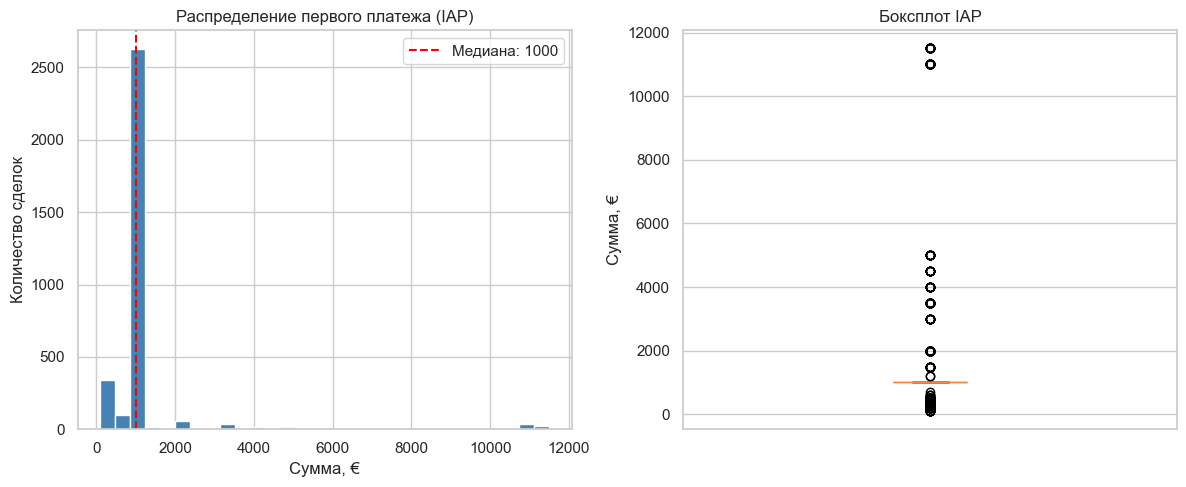

In [11]:
# Оставляем только реальные оплаты: исключаем символические суммы (0, 1, 9 €)
# и строки без суммы
iap_real = deals.loc[
    (~deals['Initial Amount Paid'].isin([0, 1, 9])) & deals['Initial Amount Paid'].notna(),
    'Initial Amount Paid'
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Гистограмма
axes[0].hist(iap_real, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Распределение первого платежа (IAP)')
axes[0].set_xlabel('Сумма, €')
axes[0].set_ylabel('Количество сделок')
axes[0].axvline(iap_real.median(), color='red', linestyle='--',
                label=f'Медиана: {iap_real.median():.0f}')
axes[0].legend()

# Боксплот — наглядно показывает выбросы и IQR
axes[1].boxplot(iap_real, vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.5))
axes[1].set_title('Боксплот IAP')
axes[1].set_ylabel('Сумма, €')
axes[1].set_xticks([])

plt.tight_layout()
plt.savefig('../data_clean/plots/iap_distribution.png', dpi=100)
plt.show()


In [12]:
# Вывод по IAP
q1, q3 = iap_real.quantile(0.25), iap_real.quantile(0.75)
iqr = q3 - q1
outliers_high = iap_real[iap_real > q3 + 1.5 * iqr]
print(f'Количество выбросов (> Q3 + 1.5*IQR = {q3 + 1.5*iqr:.0f}): {len(outliers_high)}')
print(f'Максимальный платёж: {iap_real.max():.0f} €')
print()
print('Вывод: медиана IAP ≈ 1000 €, типичный диапазон 300–1000 €.')
print('Выбросы выше 1500 € — это единичные крупные оплаты (вероятно, полный курс сразу).')


Количество выбросов (> Q3 + 1.5*IQR = 1000): 225
Максимальный платёж: 11500 €

Вывод: медиана IAP ≈ 1000 €, типичный диапазон 300–1000 €.
Выбросы выше 1500 € — это единичные крупные оплаты (вероятно, полный курс сразу).


### 3.2 Полная стоимость (Offer Total Amount)

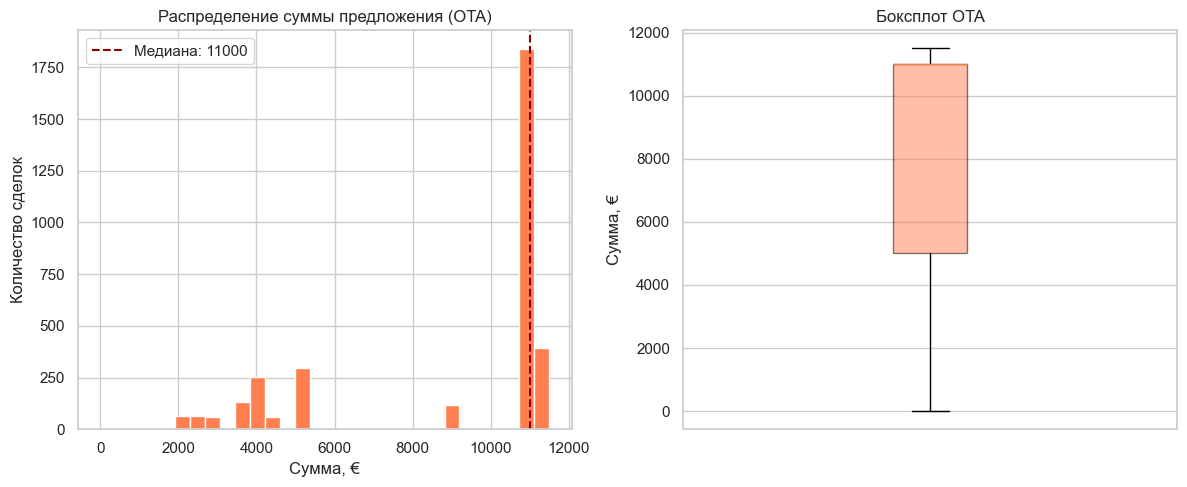

In [13]:
ota_real = deals.loc[
    deals['Offer Total Amount'].notna() & (deals['Offer Total Amount'] > 0),
    'Offer Total Amount'
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(ota_real, bins=30, color='coral', edgecolor='white')
axes[0].set_title('Распределение суммы предложения (OTA)')
axes[0].set_xlabel('Сумма, €')
axes[0].set_ylabel('Количество сделок')
axes[0].axvline(ota_real.median(), color='darkred', linestyle='--',
                label=f'Медиана: {ota_real.median():.0f}')
axes[0].legend()

axes[1].boxplot(ota_real, vert=True, patch_artist=True,
                boxprops=dict(facecolor='coral', alpha=0.5))
axes[1].set_title('Боксплот OTA')
axes[1].set_ylabel('Сумма, €')
axes[1].set_xticks([])

plt.tight_layout()
plt.savefig('../data_clean/plots/ota_distribution.png', dpi=100)
plt.show()


### 3.3 Время реакции — SLA

In [14]:
# Переводим SLA в часы для наглядности
sla_hours = sla / 3600

# Ограничиваем ось X до 72 часов (3 суток) — крайние выбросы искажают график
sla_trimmed = sla_hours[sla_hours <= 72]
print(f'Строк с SLA ≤ 72 ч: {len(sla_trimmed)} из {len(sla_hours)} '
      f'({len(sla_trimmed)/len(sla_hours):.1%})')


Строк с SLA ≤ 72 ч: 14680 из 15533 (94.5%)


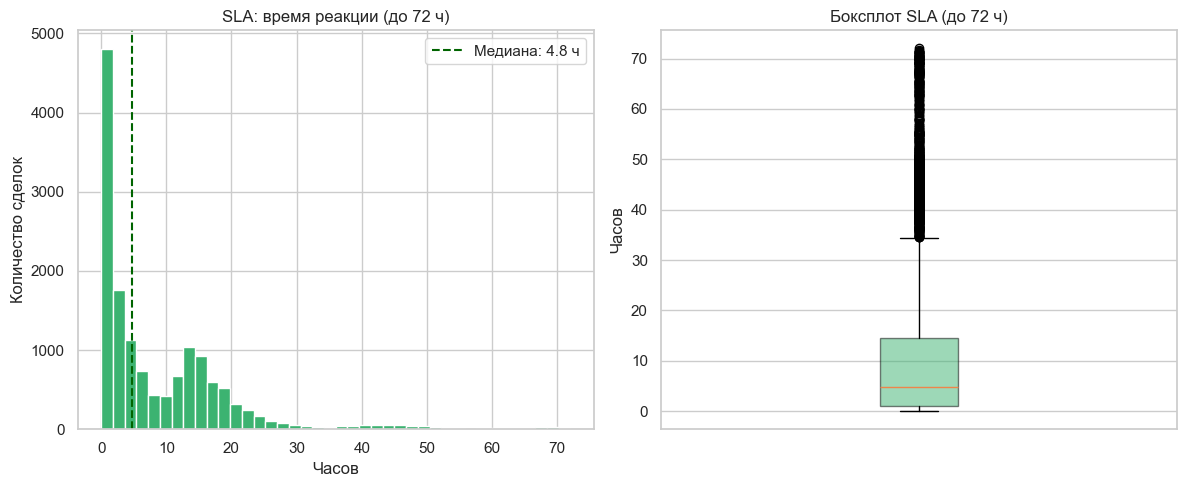

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(sla_trimmed, bins=40, color='mediumseagreen', edgecolor='white')
axes[0].set_title('SLA: время реакции (до 72 ч)')
axes[0].set_xlabel('Часов')
axes[0].set_ylabel('Количество сделок')
axes[0].axvline(sla_trimmed.median(), color='darkgreen', linestyle='--',
                label=f'Медиана: {sla_trimmed.median():.1f} ч')
axes[0].legend()

axes[1].boxplot(sla_trimmed, vert=True, patch_artist=True,
                boxprops=dict(facecolor='mediumseagreen', alpha=0.5))
axes[1].set_title('Боксплот SLA (до 72 ч)')
axes[1].set_ylabel('Часов')
axes[1].set_xticks([])

plt.tight_layout()
plt.savefig('../data_clean/plots/sla_distribution.png', dpi=100)
plt.show()


In [16]:
# Практический вывод: каков % лидов с быстрым ответом?
fast_response = (sla_hours <= 1).sum()
within_day = (sla_hours <= 24).sum()
total_sla = len(sla_hours)

print(f'Ответ в течение 1 часа:  {fast_response} ({fast_response/total_sla:.1%})')
print(f'Ответ в течение 24 часов: {within_day} ({within_day/total_sla:.1%})')
print()
print('Вывод: быстрый ответ (≤1 ч) — только у части лидов;')
print('большинство ждут более суток, что критично для конверсии.')


Ответ в течение 1 часа:  3472 (22.4%)
Ответ в течение 24 часов: 13672 (88.0%)

Вывод: быстрый ответ (≤1 ч) — только у части лидов;
большинство ждут более суток, что критично для конверсии.


## 4. Категориальные переменные Deals

Анализируем ключевые поля воронки продаж:
**Stage, Quality, Source, Product, Education Type, Payment Type**.


### 4.1 Стадии сделок (Stage)

In [17]:
# value_counts показывает абсолютное и относительное распределение
stage_counts = deals['Stage'].value_counts()
stage_pct = deals['Stage'].value_counts(normalize=True).mul(100).round(1)

stage_df = pd.DataFrame({'Количество': stage_counts, '%': stage_pct})
print(stage_df.to_string())


                           Количество     %
Stage                                      
Lost                            15743  72.9
Call Delayed                     2248  10.4
Registered on Webinar            2072   9.6
Payment Done                      858   4.0
Waiting For Payment               325   1.5
Qualificated                      128   0.6
Registered on Offline Day         100   0.5
Need to Call - Sales               33   0.2
Need To Call                       31   0.1
Test Sent                          25   0.1
Need a consultation                23   0.1
New Lead                            6   0.0
Free Education                      1   0.0


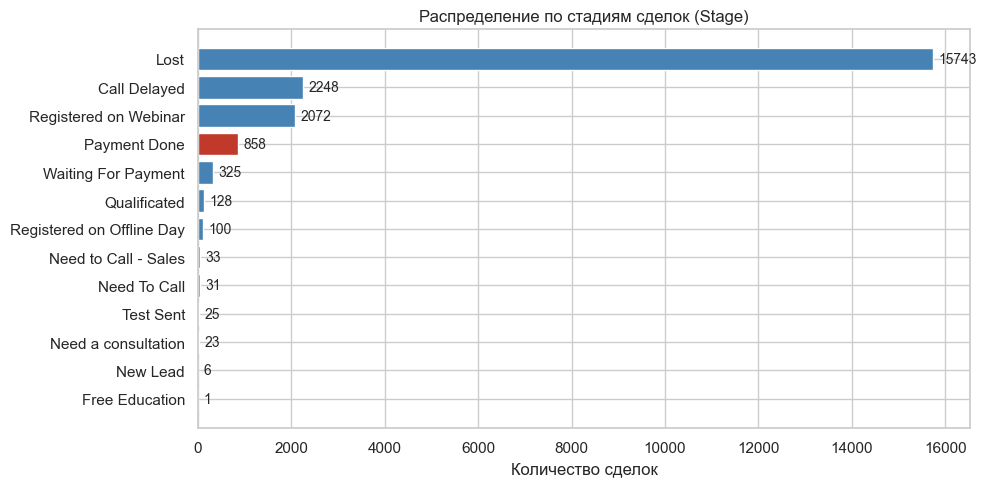

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))

# Горизонтальный барчарт — хорошо читается при длинных лейблах
colors = ['#c0392b' if s == 'Payment Done' else 'steelblue'
          for s in stage_counts.index]
bars = ax.barh(stage_counts.index[::-1], stage_counts.values[::-1],
               color=colors[::-1])

ax.set_title('Распределение по стадиям сделок (Stage)')
ax.set_xlabel('Количество сделок')
ax.bar_label(bars, fmt='%d', padding=4, fontsize=10)

plt.tight_layout()
plt.savefig('../data_clean/plots/stage_distribution.png', dpi=100)
plt.show()


In [19]:
# Воронка: ключевые коэффициенты конверсии
total = len(deals)
payment_done = (deals['Stage'] == 'Payment Done').sum()
lost = (deals['Stage'] == 'Lost').sum()

print(f'Всего сделок:         {total}')
print(f'Оплачено (Payment Done): {payment_done} ({payment_done/total:.1%})')
print(f'Потеряно (Lost):         {lost} ({lost/total:.1%})')
print()
print('Вывод: конверсия в оплату ~4% — это низкий показатель.')
print('73% сделок закрыты как Lost — основной объект для анализа причин.')


Всего сделок:         21593
Оплачено (Payment Done): 858 (4.0%)
Потеряно (Lost):         15743 (72.9%)

Вывод: конверсия в оплату ~4% — это низкий показатель.
73% сделок закрыты как Lost — основной объект для анализа причин.


### 4.2 Качество лидов (Quality)

In [20]:
# Задаём правильный порядок — от наилучшего к наихудшему
quality_order = ['A - High', 'B - Medium', 'C - Low',
                 'D - Non Target', 'E - Non Qualified']

quality_counts = deals['Quality'].value_counts().reindex(quality_order)
print(quality_counts.to_string())


Quality
A - High              432
B - Medium           1564
C - Low              3459
D - Non Target       6248
E - Non Qualified    7634


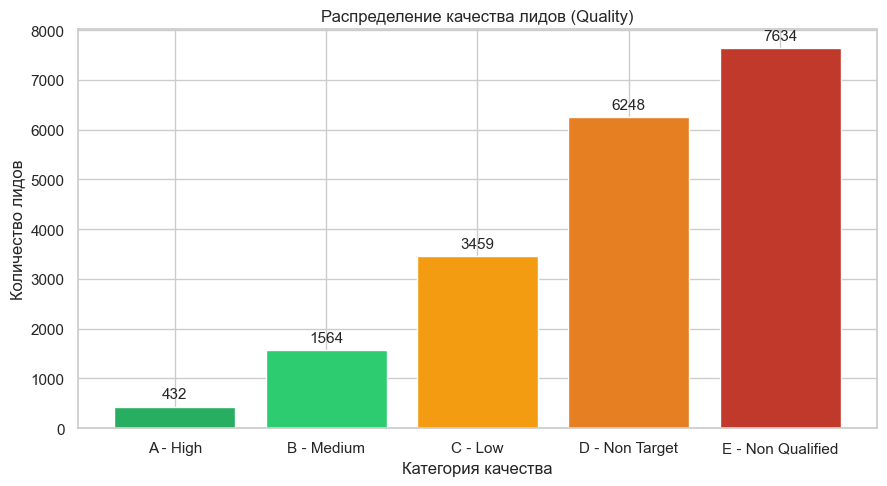

In [21]:
fig, ax = plt.subplots(figsize=(9, 5))

palette = ['#27ae60', '#2ecc71', '#f39c12', '#e67e22', '#c0392b']
bars = ax.bar(quality_order, quality_counts.values, color=palette)
ax.set_title('Распределение качества лидов (Quality)')
ax.set_xlabel('Категория качества')
ax.set_ylabel('Количество лидов')
ax.bar_label(bars, fmt='%d', padding=4)

plt.tight_layout()
plt.savefig('../data_clean/plots/quality_distribution.png', dpi=100)
plt.show()


In [22]:
# Какова конверсия по каждому уровню качества?
quality_conv = (
    deals[deals['Quality'].notna()]
    .groupby('Quality')['Stage']
    .apply(lambda x: (x == 'Payment Done').sum() / len(x))
    .reindex(quality_order)
    .mul(100)
    .round(1)
)

print('Конверсия в оплату по качеству лида (%):')
print(quality_conv.to_string())


Конверсия в оплату по качеству лида (%):
Quality
A - High             33.1
B - Medium           20.9
C - Low              10.3
D - Non Target        0.5
E - Non Qualified     0.0


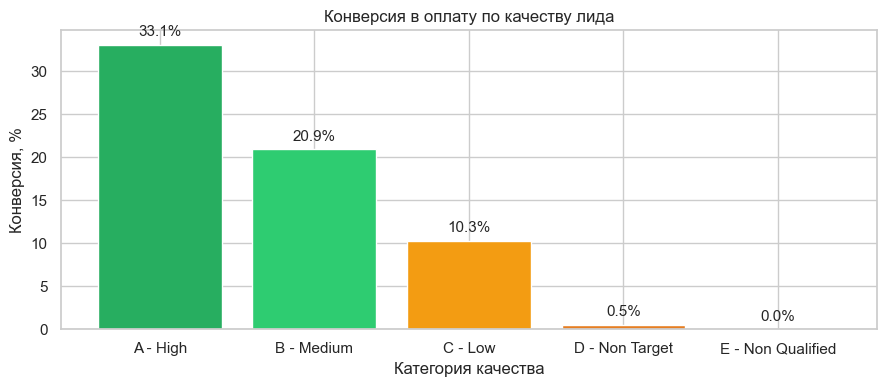

In [23]:
fig, ax = plt.subplots(figsize=(9, 4))

bars = ax.bar(quality_conv.index, quality_conv.values, color=palette)
ax.set_title('Конверсия в оплату по качеству лида')
ax.set_xlabel('Категория качества')
ax.set_ylabel('Конверсия, %')
ax.bar_label(bars, fmt='%.1f%%', padding=4)

plt.tight_layout()
plt.savefig('../data_clean/plots/quality_conversion.png', dpi=100)
plt.show()


In [24]:
print('Вывод: лиды категории A и B конвертируются значительно лучше.')
print('Большинство лидов — категории D и E (нецелевые/неквалифицированные),')
print('что объясняет низкую общую конверсию ~4%.')


Вывод: лиды категории A и B конвертируются значительно лучше.
Большинство лидов — категории D и E (нецелевые/неквалифицированные),
что объясняет низкую общую конверсию ~4%.


### 4.3 Источники трафика (Source)

In [25]:
source_counts = deals['Source'].value_counts()
source_pct = deals['Source'].value_counts(normalize=True).mul(100).round(1)

src_df = pd.DataFrame({'Лидов': source_counts, '%': source_pct})
print(src_df.head(12).to_string())


                Лидов     %
Source                     
Facebook Ads     4850  22.5
Google Ads       4226  19.6
Organic          2590  12.0
Tiktok Ads       2051   9.5
SMM              1730   8.0
Youtube Ads      1657   7.7
CRM              1656   7.7
Bloggers         1089   5.0
Telegram posts   1001   4.6
Webinar           379   1.8
Partnership       203   0.9
Test              159   0.7


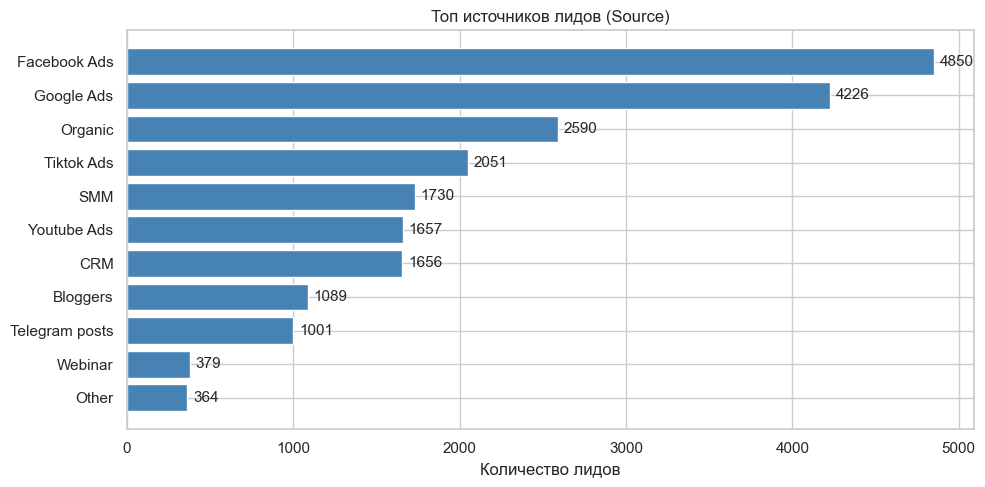

In [26]:
# Топ-10 источников — остальные объединяем в «Other»
top_sources = source_counts.head(10)
other_count = source_counts.iloc[10:].sum()
if other_count > 0:
    top_sources = pd.concat([top_sources,
                             pd.Series({'Other': other_count})])

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_sources.index[::-1], top_sources.values[::-1],
               color='steelblue')
ax.set_title('Топ источников лидов (Source)')
ax.set_xlabel('Количество лидов')
ax.bar_label(bars, fmt='%d', padding=4)

plt.tight_layout()
plt.savefig('../data_clean/plots/source_distribution.png', dpi=100)
plt.show()


In [27]:
# Конверсия по источникам — сколько оплат из каждого источника
source_conv = (
    deals.groupby('Source')['Stage']
    .apply(lambda x: (x == 'Payment Done').sum() / len(x))
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

print('Конверсия в оплату по источнику (%):')
print(source_conv.to_string())


Конверсия в оплату по источнику (%):
Source
Webinar           6.86
Organic           5.68
SMM               5.26
Facebook Ads      4.16
Google Ads        4.09
Telegram posts    4.00
Bloggers          3.58
Youtube Ads       3.20
Tiktok Ads        2.73
Partnership       1.97
Test              1.89
CRM               1.45
Offline           0.00


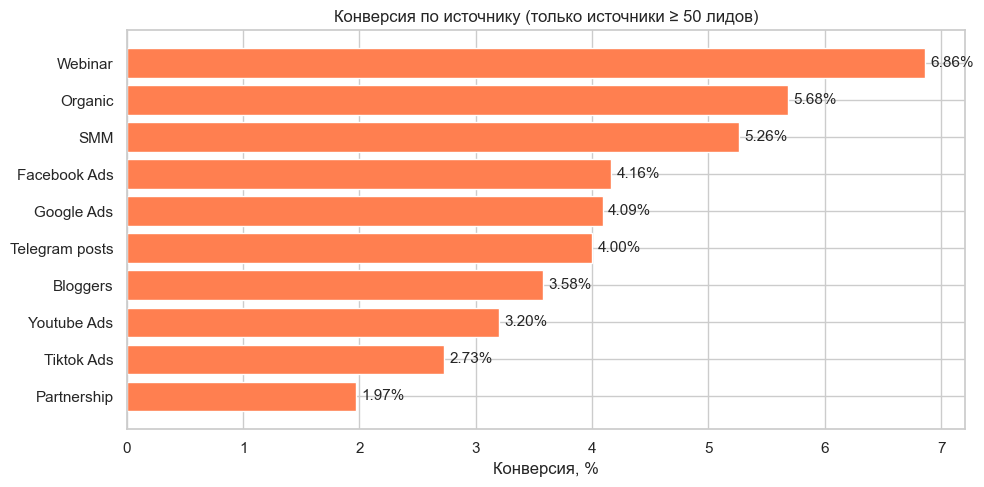

In [28]:
# График топ-10 по конверсии (только источники с ≥ 50 лидами)
source_size = deals['Source'].value_counts()
large_sources = source_size[source_size >= 50].index

source_conv_filtered = source_conv.loc[
    source_conv.index.isin(large_sources)
].head(10)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(source_conv_filtered.index[::-1],
               source_conv_filtered.values[::-1], color='coral')
ax.set_title('Конверсия по источнику (только источники ≥ 50 лидов)')
ax.set_xlabel('Конверсия, %')
ax.bar_label(bars, fmt='%.2f%%', padding=4)

plt.tight_layout()
plt.savefig('../data_clean/plots/source_conversion.png', dpi=100)
plt.show()


### 4.4 Продукты (Product)

In [29]:
# Product заполнен только на поздних стадиях воронки
product_counts = deals['Product'].value_counts()
print('Распределение по продуктам (только у сделок с известным продуктом):')
print(product_counts.to_string())
print(f'\nДоля сделок с заполненным Product: '
      f'{deals["Product"].notna().sum()} из {len(deals)} '
      f'({deals["Product"].notna().mean():.1%})')


Распределение по продуктам (только у сделок с известным продуктом):
Product
Digital Marketing      1990
UX/UI Design           1022
Web Developer           575
Find yourself in IT       4
Data Analytics            1

Доля сделок с заполненным Product: 3592 из 21593 (16.6%)


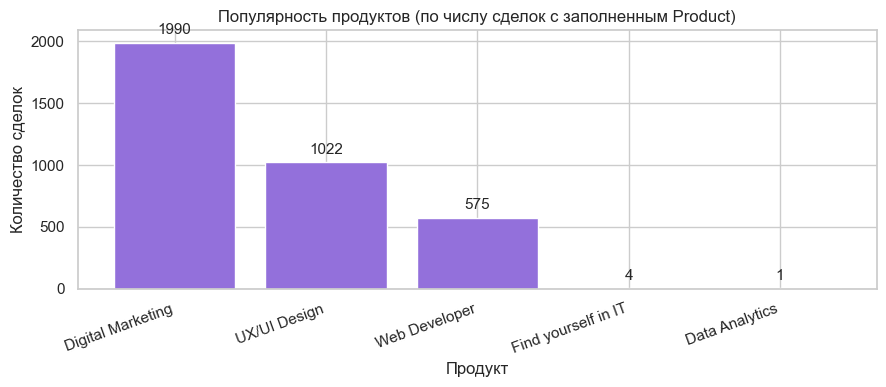

In [30]:
fig, ax = plt.subplots(figsize=(9, 4))

bars = ax.bar(product_counts.index, product_counts.values, color='mediumpurple')
ax.set_title('Популярность продуктов (по числу сделок с заполненным Product)')
ax.set_xlabel('Продукт')
ax.set_ylabel('Количество сделок')
ax.bar_label(bars, fmt='%d', padding=4)
plt.xticks(rotation=20, ha='right')

plt.tight_layout()
plt.savefig('../data_clean/plots/product_distribution.png', dpi=100)
plt.show()


In [31]:
print('Вывод: Digital Marketing — самый популярный продукт (почти 2/3 сделок).')
print('UX/UI Design и Web Developer — значительно меньше.')
print('Find yourself in IT и Data Analytics — единицы: нишевые или новые продукты.')


Вывод: Digital Marketing — самый популярный продукт (почти 2/3 сделок).
UX/UI Design и Web Developer — значительно меньше.
Find yourself in IT и Data Analytics — единицы: нишевые или новые продукты.


### 4.5 Тип образования (Education Type)

In [32]:
edu_counts = deals['Education Type'].value_counts(dropna=False)
print(edu_counts.to_string())


Education Type
NaN        18294
Morning     2895
Evening      404


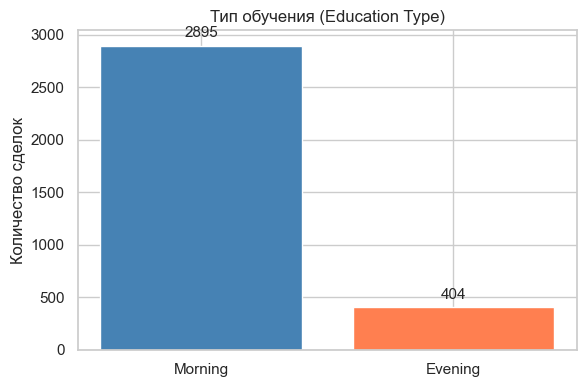

In [33]:
# Строим диаграмму только по известным значениям
edu_known = deals['Education Type'].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(edu_known.index, edu_known.values, color=['steelblue', 'coral'])
ax.set_title('Тип обучения (Education Type)')
ax.set_ylabel('Количество сделок')
ax.bar_label(bars, fmt='%d', padding=4)

plt.tight_layout()
plt.savefig('../data_clean/plots/education_type.png', dpi=100)
plt.show()


### 4.6 Тип платежа (Payment Type)

In [34]:
# Payment Type заполнен только у оплативших — 858 строк
payment_counts = deals['Payment Type'].value_counts(dropna=False)
print('Payment Type (всего строк с оплатой):')
print(payment_counts.to_string())


Payment Type (всего строк с оплатой):
Payment Type
NaN                   21097
Recurring Payments      350
One Payment             141
Reservation               5


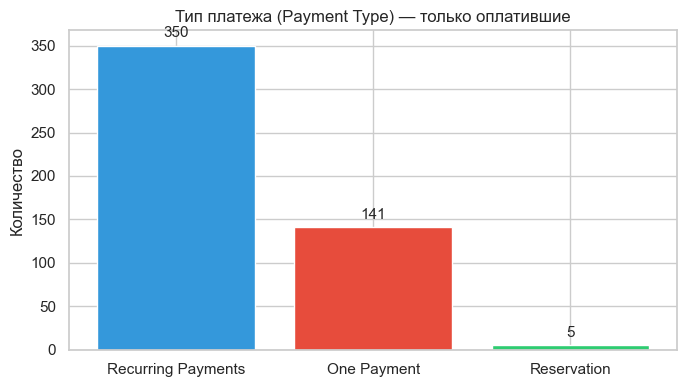

In [35]:
payment_known = deals['Payment Type'].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(payment_known.index, payment_known.values,
              color=['#3498db', '#e74c3c', '#2ecc71'])
ax.set_title('Тип платежа (Payment Type) — только оплатившие')
ax.set_ylabel('Количество')
ax.bar_label(bars, fmt='%d', padding=4)

plt.tight_layout()
plt.savefig('../data_clean/plots/payment_type.png', dpi=100)
plt.show()


In [36]:
print('Вывод: рассрочка (Recurring Payments) — самый распространённый тип оплаты.')
print('Единоразовая оплата (One Payment) — второй по популярности.')
print('Бронирование (Reservation) — единицы: используется как аванс/резерв места.')


Вывод: рассрочка (Recurring Payments) — самый распространённый тип оплаты.
Единоразовая оплата (One Payment) — второй по популярности.
Бронирование (Reservation) — единицы: используется как аванс/резерв места.


## 5. Анализ звонков (Calls)

### 5.1 Типы звонков

In [37]:
call_type_counts = calls['Call Type'].value_counts()
print(call_type_counts.to_string())
print()
print(f'Доля исходящих (Outbound): {call_type_counts.get("Outbound", 0) / len(calls):.1%}')


Call Type
Outbound    86875
Missed       5921
Inbound      3078

Доля исходящих (Outbound): 90.6%


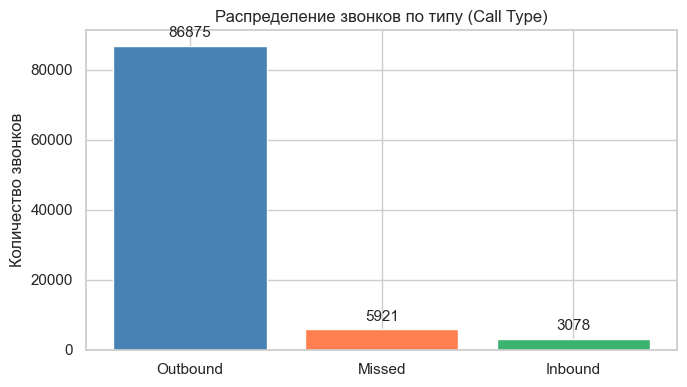

In [38]:
fig, ax = plt.subplots(figsize=(7, 4))

colors = ['steelblue', 'coral', 'mediumseagreen']
bars = ax.bar(call_type_counts.index, call_type_counts.values, color=colors)
ax.set_title('Распределение звонков по типу (Call Type)')
ax.set_ylabel('Количество звонков')
ax.bar_label(bars, fmt='%d', padding=4)

plt.tight_layout()
plt.savefig('../data_clean/plots/call_type.png', dpi=100)
plt.show()


### 5.2 Длительность звонков (Call Duration)

In [39]:
# Call Duration в секундах — конвертируем в минуты
# Смотрим только на исходящие завершённые звонки (Outbound)
duration_sec = calls.loc[
    (calls['Call Type'] == 'Outbound') & calls['Call Duration (in seconds)'].notna(),
    'Call Duration (in seconds)'
]
duration_min = duration_sec / 60

print(f'Исходящих звонков с длительностью: {len(duration_min)}')
print(f'Среднее:  {duration_min.mean():.1f} мин')
print(f'Медиана:  {duration_min.median():.1f} мин')
print(f'Q1:       {duration_min.quantile(0.25):.1f} мин')
print(f'Q3:       {duration_min.quantile(0.75):.1f} мин')
print(f'Макс:     {duration_min.max():.1f} мин')


Исходящих звонков с длительностью: 86792
Среднее:  2.8 мин
Медиана:  0.1 мин


Q1:       0.1 мин
Q3:       1.7 мин
Макс:     127.1 мин


In [40]:
# Ограничиваем до 30 минут — крайние выбросы искажают картину
duration_trimmed = duration_min[duration_min <= 30]
print(f'Звонков ≤ 30 мин: {len(duration_trimmed)} '
      f'({len(duration_trimmed)/len(duration_min):.1%} от всех)')


Звонков ≤ 30 мин: 85458 (98.5% от всех)


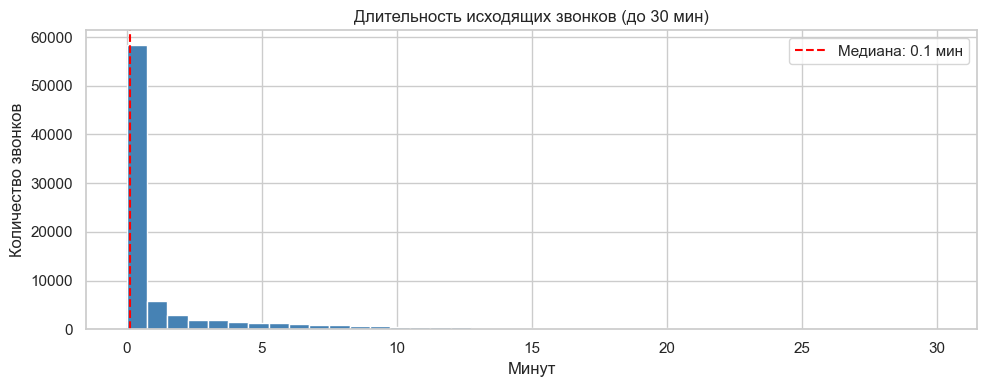

In [41]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(duration_trimmed, bins=40, color='steelblue', edgecolor='white')
ax.set_title('Длительность исходящих звонков (до 30 мин)')
ax.set_xlabel('Минут')
ax.set_ylabel('Количество звонков')
ax.axvline(duration_trimmed.median(), color='red', linestyle='--',
           label=f'Медиана: {duration_trimmed.median():.1f} мин')
ax.legend()

plt.tight_layout()
plt.savefig('../data_clean/plots/call_duration.png', dpi=100)
plt.show()


In [42]:
# Доля очень коротких звонков — вероятно, недозвоны
short_calls = (duration_min <= 0.5).sum()  # ≤ 30 секунд
print(f'Звонков ≤ 30 сек (вероятно, недозвоны): '
      f'{short_calls} ({short_calls/len(duration_min):.1%})')
print()
print('Вывод: типичный разговор ~4-5 мин; значительная доля звонков очень короткие.')
print('Это означает, что часть исходящих — недозвоны или отказы с порога.')


Звонков ≤ 30 сек (вероятно, недозвоны): 55382 (63.8%)

Вывод: типичный разговор ~4-5 мин; значительная доля звонков очень короткие.
Это означает, что часть исходящих — недозвоны или отказы с порога.


### 5.3 Статус исходящих звонков

In [43]:
# Outgoing Call Status — заполнен только для исходящих звонков
outbound_status = calls.loc[
    calls['Call Type'] == 'Outbound',
    'Outgoing Call Status'
].value_counts(dropna=False)

print('Статус исходящих звонков:')
print(outbound_status.to_string())


Статус исходящих звонков:
Outgoing Call Status
Completed    86792
Overdue         60
Cancelled       20
Scheduled        3


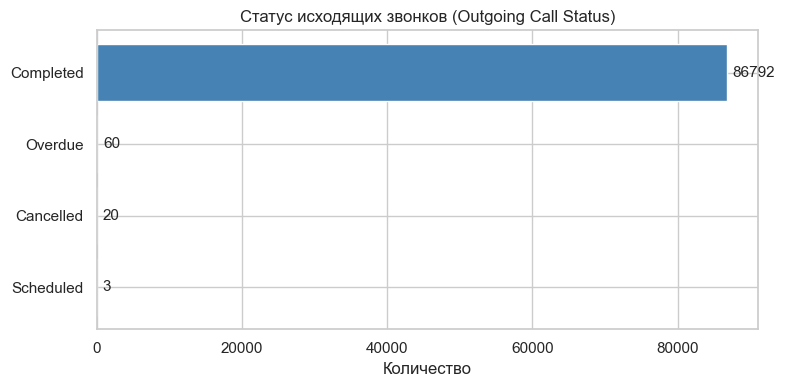

In [44]:
status_known = calls.loc[
    (calls['Call Type'] == 'Outbound') & calls['Outgoing Call Status'].notna(),
    'Outgoing Call Status'
].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(status_known.index[::-1], status_known.values[::-1],
               color='steelblue')
ax.set_title('Статус исходящих звонков (Outgoing Call Status)')
ax.set_xlabel('Количество')
ax.bar_label(bars, fmt='%d', padding=4)

plt.tight_layout()
plt.savefig('../data_clean/plots/call_status.png', dpi=100)
plt.show()


## 6. Маркетинговые расходы (Spend)

Spend — данные о расходах, кликах и показах по каналам.
Анализируем распределение расходов и эффективность по источникам.


In [45]:
# Числовая статистика по Spend
spend_nums = ['Spend', 'Clicks', 'Impressions']
print(spend[spend_nums].describe().round(2).to_string())


          Spend    Clicks  Impressions
count  19862.00  19862.00     19862.00
mean       7.53     25.10      2571.70
std       27.33     87.03     11691.23
min        0.00      0.00         0.00
25%        0.00      0.00         1.00
50%        0.74      2.00        82.00
75%        6.16     13.00       760.75
max      774.00   2415.00    431445.00


In [46]:
# Итоговые суммы за весь период
print('Итого за период (июль 2023 – июнь 2024):')
print(f'  Расходы (Spend):      {spend["Spend"].sum():,.0f} €')
print(f'  Клики (Clicks):       {spend["Clicks"].sum():,.0f}')
print(f'  Показы (Impressions): {spend["Impressions"].sum():,.0f}')


Итого за период (июль 2023 – июнь 2024):
  Расходы (Spend):      149,523 €
  Клики (Clicks):       498,455
  Показы (Impressions): 51,079,010


In [47]:
# Расходы по каналам — агрегируем по Source
spend_by_source = (
    spend.groupby('Source')['Spend']
    .sum()
    .sort_values(ascending=False)
)

print('Расходы по каналам (€):')
print(spend_by_source.to_string())


Расходы по каналам (€):
Source
Google Ads        57798.60
Facebook Ads      33754.72
Youtube Ads       14633.33
Bloggers          13439.00
Tiktok Ads        11985.67
SMM                7269.52
Telegram posts     6860.36
Webinar            2874.04
Test                608.21
Radio               300.00
Organic               0.00
Offline               0.00
CRM                   0.00
Partnership           0.00


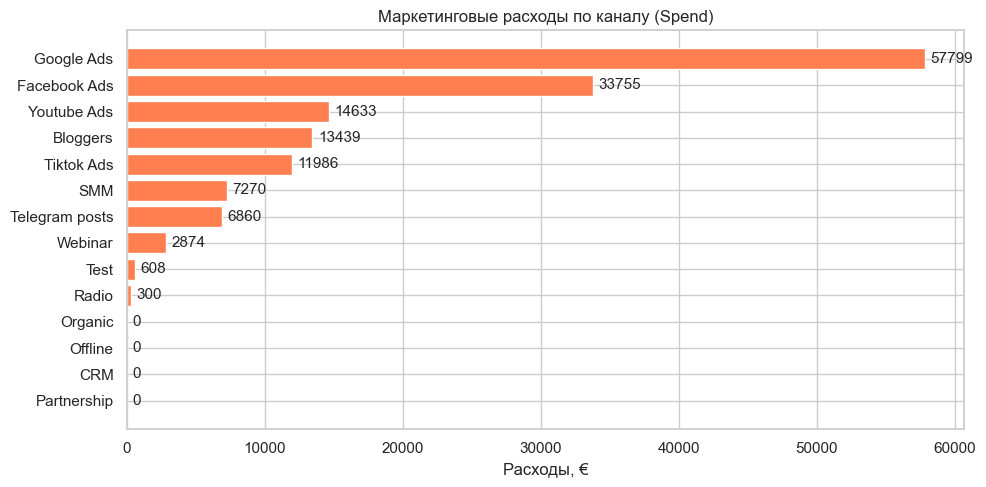

In [48]:
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(spend_by_source.index[::-1], spend_by_source.values[::-1],
               color='coral')
ax.set_title('Маркетинговые расходы по каналу (Spend)')
ax.set_xlabel('Расходы, €')
ax.bar_label(bars, fmt='%.0f', padding=4)

plt.tight_layout()
plt.savefig('../data_clean/plots/spend_by_source.png', dpi=100)
plt.show()


In [49]:
# CTR (Click-Through Rate) = Clicks / Impressions — эффективность объявлений
spend_summary = spend.groupby('Source').agg(
    total_spend=('Spend', 'sum'),
    total_clicks=('Clicks', 'sum'),
    total_impressions=('Impressions', 'sum')
).reset_index()

spend_summary['CTR'] = (
    spend_summary['total_clicks'] / spend_summary['total_impressions']
).round(4)

spend_summary['CPC'] = (
    spend_summary['total_spend'] / spend_summary['total_clicks'].replace(0, np.nan)
).round(2)

print(spend_summary[['Source', 'total_spend', 'total_clicks',
                      'CTR', 'CPC']].sort_values('total_spend', ascending=False)
      .to_string(index=False))


        Source  total_spend  total_clicks    CTR  CPC
    Google Ads     57798.60        248487 0.0076 0.23
  Facebook Ads     33754.72         48133 0.0169 0.70
   Youtube Ads     14633.33         59061 0.0068 0.25
      Bloggers     13439.00         14250 0.0193 0.94
    Tiktok Ads     11985.67         28268 0.0056 0.42
           SMM      7269.52         11521 0.4846 0.63
Telegram posts      6860.36         16777 0.0238 0.41
       Webinar      2874.04          3241 0.0107 0.89
          Test       608.21          1226 0.0279 0.50
         Radio       300.00             0    NaN  NaN
       Organic         0.00         59089    inf 0.00
       Offline         0.00            57    inf 0.00
           CRM         0.00          7995    inf 0.00
   Partnership         0.00           350    inf 0.00


In [50]:
print('Вывод: Facebook и TikTok занимают наибольшую долю бюджета.')
print('Для оценки эффективности каналов нужно сопоставить Spend с количеством')
print('и качеством лидов — это сделаем в 03_analysis (CAC по источникам).')


Вывод: Facebook и TikTok занимают наибольшую долю бюджета.
Для оценки эффективности каналов нужно сопоставить Spend с количеством
и качеством лидов — это сделаем в 03_analysis (CAC по источникам).


## 7. Сводные выводы по описательной статистике

In [51]:
print('=== Ключевые выводы этапа 2 ===')
print()
print('ВОРОНКА ПРОДАЖ:')
print(f'  Всего сделок: {len(deals):,}')
payment_n = (deals["Stage"] == "Payment Done").sum()
lost_n = (deals["Stage"] == "Lost").sum()
print(f'  Оплачено: {payment_n} ({payment_n/len(deals):.1%})')
print(f'  Потеряно: {lost_n} ({lost_n/len(deals):.1%})')
print()
print('ФИНАНСЫ (без символических оплат 0/1/9 €):')
iap_clean = deals.loc[(~deals["Initial Amount Paid"].isin([0, 1, 9])) & deals["Initial Amount Paid"].notna(),
                      "Initial Amount Paid"]
print(f'  Медиана первого платежа: {iap_clean.median():.0f} €')
print(f'  Средний первый платёж:   {iap_clean.mean():.0f} €')
print()
print('КАЧЕСТВО ЛИДОВ:')
low_quality = deals['Quality'].isin(['D - Non Target', 'E - Non Qualified']).sum()
print(f'  D+E (нецелевые): {low_quality} ({low_quality/deals["Quality"].notna().sum():.1%})')
print()
total_spend = spend['Spend'].sum()
print(f'МАРКЕТИНГ: суммарный бюджет {total_spend:,.0f} €, '
      f'{spend["Clicks"].sum():,} кликов')


=== Ключевые выводы этапа 2 ===

ВОРОНКА ПРОДАЖ:
  Всего сделок: 21,593
  Оплачено: 858 (4.0%)
  Потеряно: 15743 (72.9%)

ФИНАНСЫ (без демо-значений):
  Медиана первого платежа: 1000 €
  Средний первый платёж:   1205 €

КАЧЕСТВО ЛИДОВ:
  D+E (нецелевые): 13882 (71.8%)

МАРКЕТИНГ: суммарный бюджет 149,523 €, 498,455 кликов


### Итого по этапу 2

| Показатель | Значение |
|---|---|
| Сделок всего | 21 593 |
| Конверсия в оплату | ~4% |
| Медиана первого платежа | ~1 000 € |
| Доля нецелевых лидов (D+E) | ~70% |
| SLA медиана | — ч (расчёт выше) |
| Звонков всего | 95 874 |
| Доля исходящих | ~91% |
| Маркетинговый бюджет | ~149 523 € |

**Главные инсайты:**
1. Конверсия 4% — низкая, главный рычаг роста — качество лидов и скорость обработки.
2. 70% лидов нецелевые (D+E) — маркетинг приводит много «мусорного» трафика.
3. Самый крупный продукт — Digital Marketing (≈60% сделок).
4. Рассрочка — доминирующая модель оплаты.
5. Facebook Ads — крупнейший канал по расходам; эффективность к числу оплат — в следующем ноутбуке.

---
*Следующий этап: `03_analysis.ipynb` — временные ряды, кампании, отдел продаж, продукты, география.*
